In [32]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
!pip install xgboost

In [34]:
df = pd.read_csv("/content/heart_disease_uci (1).csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [36]:
df.describe(include='all')

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


In [37]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [38]:
df.dropna(inplace=True)
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,300,68,Male,Cleveland,asymptomatic,144.0,193.0,True,normal,141.0,False,3.4,flat,2.0,reversable defect,2
300,301,57,Male,Cleveland,asymptomatic,130.0,131.0,False,normal,115.0,True,1.2,flat,1.0,reversable defect,3
301,302,57,Female,Cleveland,atypical angina,130.0,236.0,False,lv hypertrophy,174.0,False,0.0,flat,1.0,normal,1
508,509,47,Male,Hungary,asymptomatic,150.0,226.0,False,normal,98.0,True,1.5,flat,0.0,reversable defect,1


In [39]:
df.duplicated().sum()

np.int64(0)

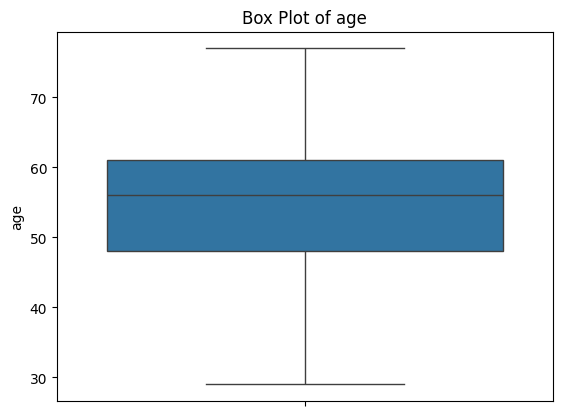

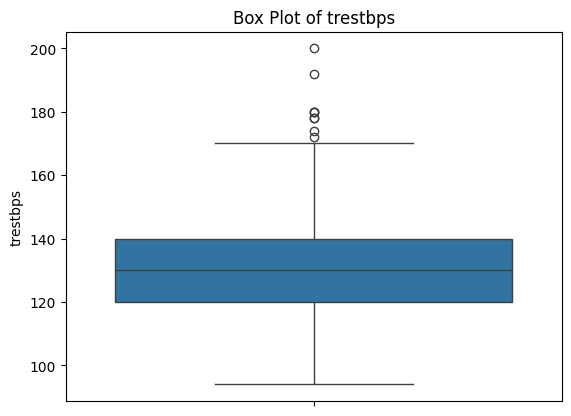

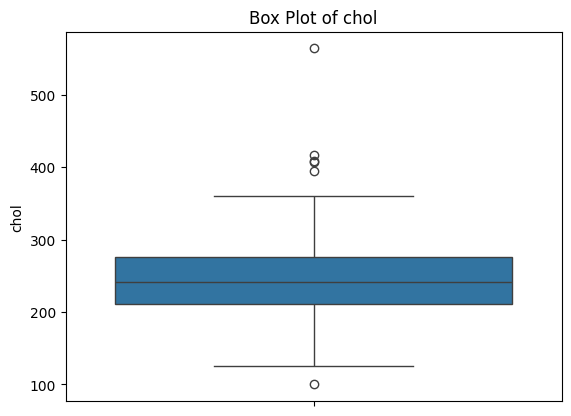

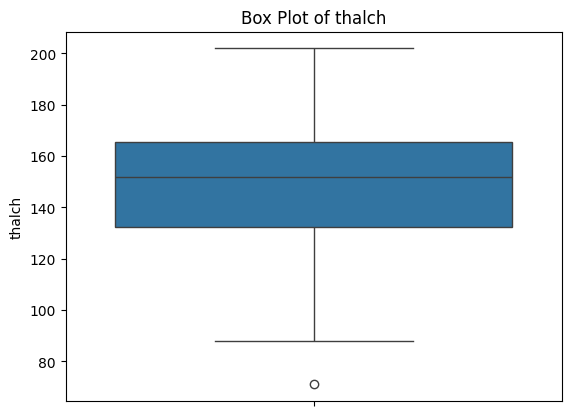

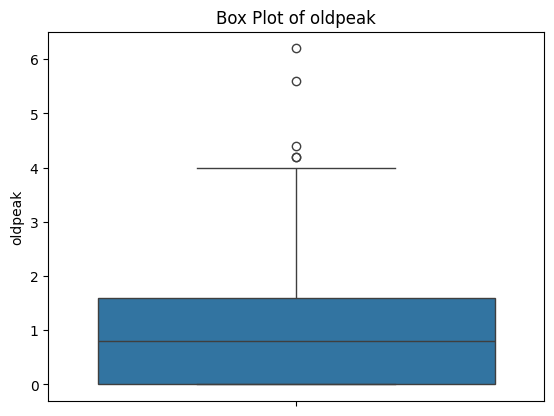

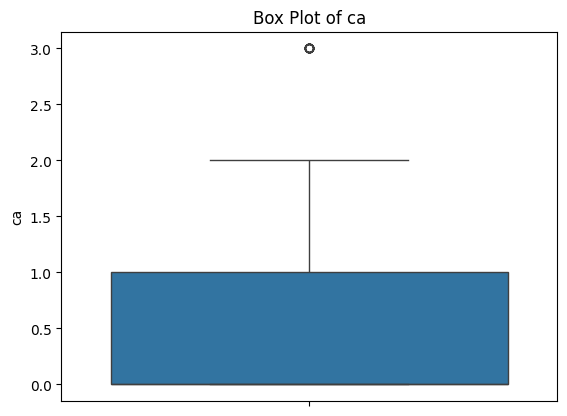

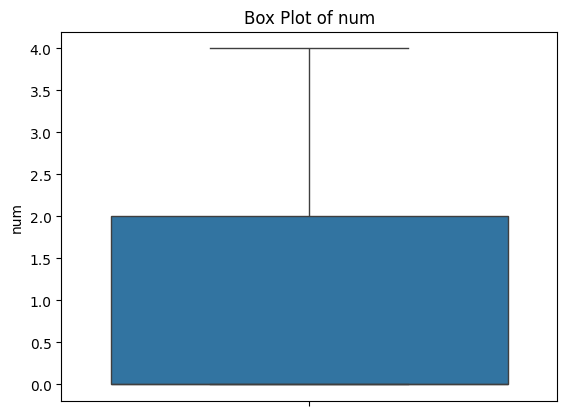

In [40]:
numerical_features = ['age','trestbps','chol','thalch','oldpeak','ca','num']

for feature in numerical_features:
    sns.boxplot(df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

In [41]:
for feature in numerical_features:
    q1, q3 = np.percentile(df[feature], [25, 75])
    iqr = q3 - q1
    minimum = q1 - 1.5 * iqr
    maximum = q3 + 1.5 * iqr
    df = df[(df[feature] >= minimum) & (df[feature] <= maximum)]
    print(f"Outliers removed from {feature}")
df

Outliers removed from age
Outliers removed from trestbps
Outliers removed from chol
Outliers removed from thalch
Outliers removed from oldpeak
Outliers removed from ca
Outliers removed from num


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,298,57,Female,Cleveland,asymptomatic,140.0,241.0,False,normal,123.0,True,0.2,flat,0.0,reversable defect,1
298,299,45,Male,Cleveland,typical angina,110.0,264.0,False,normal,132.0,False,1.2,flat,0.0,reversable defect,1
299,300,68,Male,Cleveland,asymptomatic,144.0,193.0,True,normal,141.0,False,3.4,flat,2.0,reversable defect,2
301,302,57,Female,Cleveland,atypical angina,130.0,236.0,False,lv hypertrophy,174.0,False,0.0,flat,1.0,normal,1


In [42]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['dataset'] = le.fit_transform(df['dataset'])
df['cp'] = le.fit_transform(df['cp'])
df['restecg'] = le.fit_transform(df['restecg'])
df['exang'] = le.fit_transform(df['exang'])
df['slope'] = le.fit_transform(df['slope'])
df['thal'] = le.fit_transform(df['thal'])
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,True,0,150.0,0,2.3,0,0.0,0,0
2,3,67,1,0,0,120.0,229.0,False,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,False,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,False,0,172.0,0,1.4,2,0.0,1,0
5,6,56,1,0,1,120.0,236.0,False,1,178.0,0,0.8,2,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,298,57,0,0,0,140.0,241.0,False,1,123.0,1,0.2,1,0.0,2,1
298,299,45,1,0,3,110.0,264.0,False,1,132.0,0,1.2,1,0.0,2,1
299,300,68,1,0,0,144.0,193.0,True,1,141.0,0,3.4,1,2.0,2,2
301,302,57,0,0,1,130.0,236.0,False,0,174.0,0,0.0,1,1.0,1,1


In [43]:
#Feature Scaling- Numerical Only - MinMax Scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,0.723404,1,0,3,0.671053,0.457265,True,0,0.543860,0,0.575,0,0.0,0,0.0
2,3,0.808511,1,0,0,0.342105,0.440171,False,0,0.359649,1,0.650,1,1.0,2,0.5
3,4,0.170213,1,0,2,0.473684,0.529915,False,1,0.868421,0,0.875,0,0.0,1,0.0
4,5,0.255319,0,0,1,0.473684,0.333333,False,0,0.736842,0,0.350,2,0.0,1,0.0
5,6,0.574468,1,0,1,0.342105,0.470085,False,1,0.789474,0,0.200,2,0.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,298,0.595745,0,0,0,0.605263,0.491453,False,1,0.307018,1,0.050,1,0.0,2,0.5
298,299,0.340426,1,0,3,0.210526,0.589744,False,1,0.385965,0,0.300,1,0.0,2,0.5
299,300,0.829787,1,0,0,0.657895,0.286325,True,1,0.464912,0,0.850,1,1.0,2,1.0
301,302,0.595745,0,0,1,0.473684,0.470085,False,0,0.754386,0,0.000,1,0.5,1,0.5


In [44]:
# Dataset Splitting for Training and testing
from sklearn.model_selection import train_test_split
X = df.drop('num', axis=1)
y = df['num']

y = (y > 0.5).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 42)

In [45]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (183, 15)
Shape of X_test:  (46, 15)
Shape of y_train:  (183,)
Shape of y_test:  (46,)


In [46]:
# Model Selection Training - Logistic Regression

lr = LogisticRegression() #object / instance creation
lr.fit(X_train, y_train) # Training

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [47]:
y_test

,num
288,0
81,0
11,0
258,0
18,0
267,1
31,1
260,0
212,0
162,0


In [48]:
X_test

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
288,289,0.574468,1,0,1,0.473684,0.405983,False,0,0.657895,0,0.000,2,0.0,2
81,82,0.510638,0,0,0,0.473684,0.589744,False,0,0.482456,0,0.100,1,0.0,1
11,12,0.574468,0,0,1,0.605263,0.717949,False,0,0.570175,0,0.325,1,0.0,1
258,259,0.872340,1,0,1,0.815789,0.508547,False,0,0.482456,0,0.000,2,0.0,1
18,19,0.404255,0,0,2,0.473684,0.636752,False,1,0.447368,0,0.050,2,0.0,1
267,268,0.638298,1,0,2,0.421053,0.393162,True,1,0.403509,0,0.550,1,0.5,0
31,32,0.659574,1,0,0,0.302632,0.444444,True,1,0.631579,1,0.350,2,1.0,2
260,261,0.319149,0,0,2,0.315789,0.495726,False,1,0.535088,0,0.075,1,0.5,1
212,213,0.255319,1,0,2,0.473684,0.376068,False,0,0.701754,0,0.500,1,0.0,1
162,163,0.531915,0,0,2,0.210526,0.376068,False,1,0.614035,0,0.400,1,0.0,1


In [49]:
y_pred = lr.predict(X_test) #Evaluation
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [50]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8913043478260869


In [51]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  1]
 [ 4  1]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        41
           1       0.50      0.20      0.29         5

    accuracy                           0.89        46
   macro avg       0.70      0.59      0.61        46
weighted avg       0.86      0.89      0.87        46



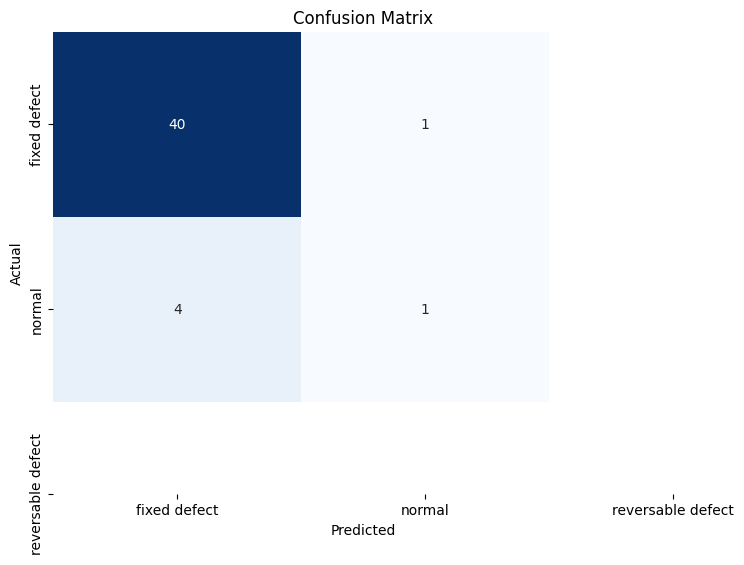

In [52]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [53]:
#Selected Model- kNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [54]:
y_pred = knn.predict(X_test)

In [55]:
#Accucary, COnfusion Matrix, Classification
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8695652173913043
[[40  1]
 [ 5  0]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93        41
           1       0.00      0.00      0.00         5

    accuracy                           0.87        46
   macro avg       0.44      0.49      0.47        46
weighted avg       0.79      0.87      0.83        46



In [56]:
# Model - Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

In [57]:
# testing
y_pred = dtc.predict(X_test)

In [58]:
# Accuracy, Confusion Matrix Classification Report
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8260869565217391
[[37  4]
 [ 4  1]]
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        41
           1       0.20      0.20      0.20         5

    accuracy                           0.83        46
   macro avg       0.55      0.55      0.55        46
weighted avg       0.83      0.83      0.83        46



In [59]:
# scale it
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [60]:
# Model - SVM
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [61]:
y_pred = svc.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9130434782608695
[[40  1]
 [ 3  2]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        41
           1       0.67      0.40      0.50         5

    accuracy                           0.91        46
   macro avg       0.80      0.69      0.73        46
weighted avg       0.90      0.91      0.90        46

